# 05 Collaborative Filtering

Bu notebook kullanıcı-ürün etkileşimlerinden yararlanarak collaborative filtering modelleri kurar.

Karşılaştırılan iki CF varyantı:
- TruncatedSVD tabanlı explicit-feedback yaklaşımı
- LightFM tabanlı implicit-ranking yaklaşımı


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_INTERIM = PROJECT_ROOT / "data_interim"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.advanced_models import train_lightfm_model

cf_data = pd.read_csv(DATA_INTERIM / "reviews_cf_last.csv")
cf_data["author_id"] = cf_data["author_id"].astype(str)
cf_data["product_id"] = cf_data["product_id"].astype(str)
cf_data["submission_time"] = pd.to_datetime(cf_data["submission_time"], errors="coerce")

display(cf_data.head())


In [2]:
user_interaction_counts = cf_data.groupby("author_id")["product_id"].count().sort_values(ascending=False)
eligible_users = user_interaction_counts[user_interaction_counts >= 5].index
cf_filtered = cf_data[cf_data["author_id"].isin(eligible_users)].copy()

sparsity = 1 - (cf_filtered[["author_id", "product_id"]].drop_duplicates().shape[0] / (cf_filtered["author_id"].nunique() * cf_filtered["product_id"].nunique()))

print("Original shape:", cf_data.shape)
print("Filtered shape:", cf_filtered.shape)
print("Eligible users:", len(eligible_users))
print(f"Approximate matrix sparsity: {sparsity:.4f}")


Original shape: (1088886, 4)
Filtered shape: (370956, 4)
Eligible users: 40433
Approximate matrix sparsity: 0.9959


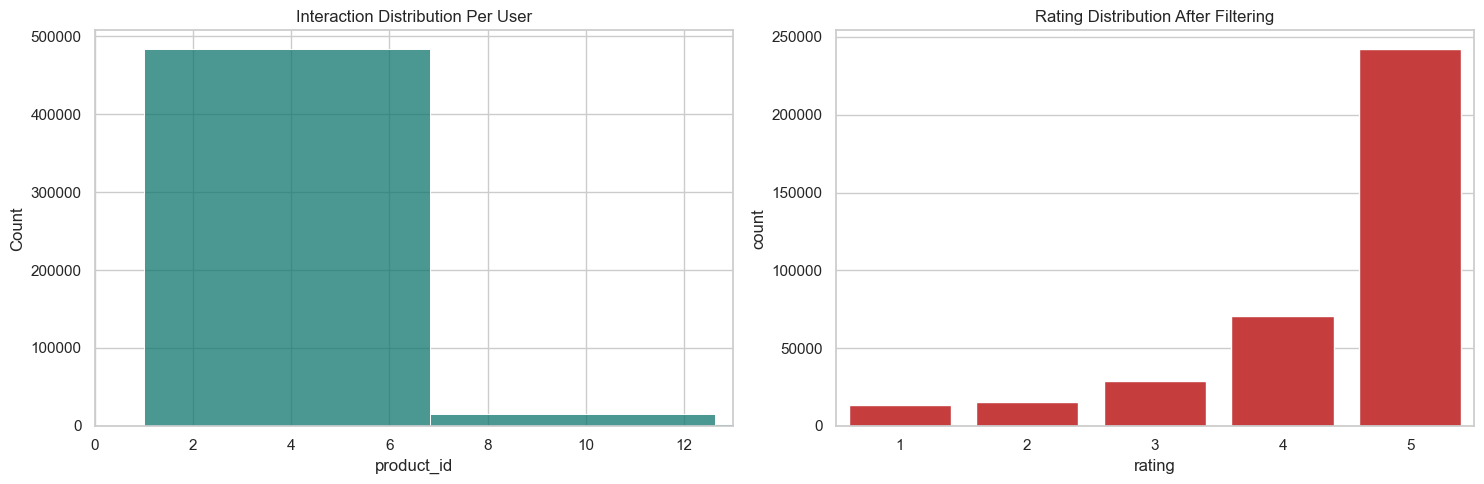

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(user_interaction_counts, bins=50, color="#0F766E", ax=axes[0])
axes[0].set_title("Interaction Distribution Per User")
axes[0].set_xlim(0, user_interaction_counts.quantile(0.99))

rating_dist = cf_filtered["rating"].value_counts().sort_index().reset_index()
rating_dist.columns = ["rating", "count"]
sns.barplot(data=rating_dist, x="rating", y="count", color="#DC2626", ax=axes[1])
axes[1].set_title("Rating Distribution After Filtering")

plt.tight_layout()


## Grafik Yorumu

Etkileşim sayısı dağılımı ve filtrelenmiş rating dağılımı birlikte değerlendirildiğinde collaborative filtering modelinin yoğun veri üreten kullanıcılar üzerinden öğrenme eğiliminde olduğu görülmektedir. Bu nedenle düşük etkileşimli kullanıcıların modele katkısı sınırlı kalabilir.


In [4]:
user_ids = cf_filtered["author_id"].unique()
item_ids = cf_filtered["product_id"].unique()
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}

cf_filtered["user_idx"] = cf_filtered["author_id"].map(user_to_idx)
cf_filtered["item_idx"] = cf_filtered["product_id"].map(item_to_idx)

user_item_matrix = csr_matrix(
    (cf_filtered["rating"], (cf_filtered["user_idx"], cf_filtered["item_idx"])),
    shape=(len(user_ids), len(item_ids))
)

print("Matrix shape:", user_item_matrix.shape)


Matrix shape: (40433, 2257)


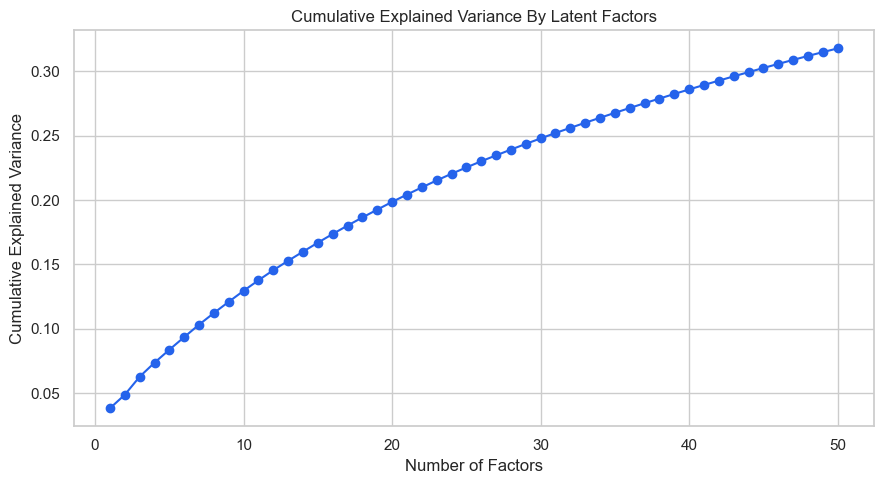

In [5]:
n_factors = 50
svd = TruncatedSVD(n_components=n_factors, random_state=42)
user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_.T
predicted_scores = user_factors @ item_factors.T
explained_variance = svd.explained_variance_ratio_.cumsum()

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o", color="#2563EB")
plt.title("Cumulative Explained Variance By Latent Factors")
plt.xlabel("Number of Factors")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()


## Grafik Yorumu

Açıklanan varyans eğrisi, seçilen latent faktör sayısının kullanıcı-ürün matrisindeki yapıyı ne ölçüde temsil ettiğini göstermektedir. Eğrinin yataylaşmaya başladığı bölge, model karmaşıklığı ile temsil gücü arasındaki dengeyi değerlendirmek için kullanılabilir.


In [6]:
def recommend_cf(user_id, top_n=10):
    if user_id not in user_to_idx:
        return None

    user_idx = user_to_idx[user_id]
    scores = predicted_scores[user_idx]
    seen_items = set(cf_filtered.loc[cf_filtered["author_id"] == user_id, "product_id"])

    rec_df = pd.DataFrame({"product_id": item_ids, "cf_score": scores})
    rec_df = rec_df[~rec_df["product_id"].isin(seen_items)]
    return rec_df.sort_values("cf_score", ascending=False).head(top_n)


,product_id,cf_score
298,P394624,0.871426
280,P427417,0.600126
315,P248407,0.406917
177,P427419,0.376777
75,P422905,0.353213
187,P218700,0.330325
73,P421275,0.319937
299,P427406,0.313874
124,P449175,0.271867
60,P297524,0.264191


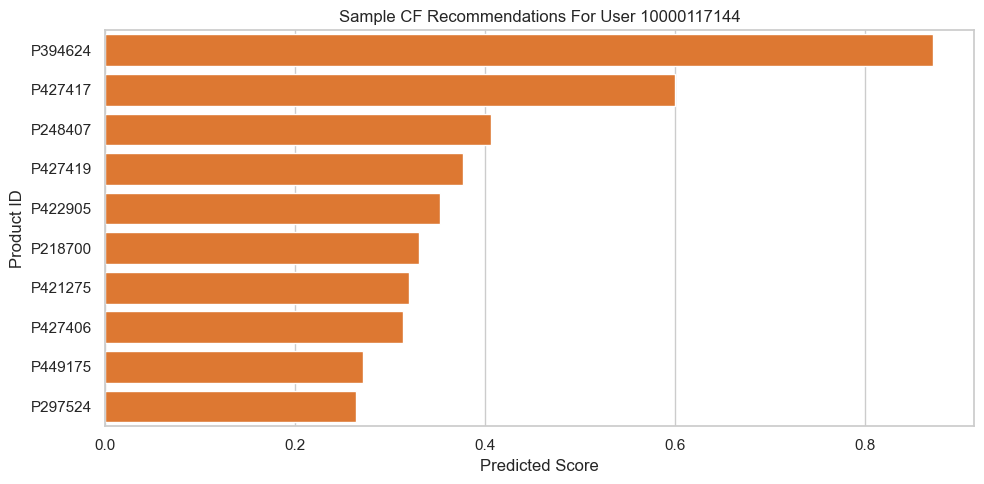

In [7]:
sample_user_id = cf_filtered["author_id"].iloc[0]
sample_cf = recommend_cf(sample_user_id, top_n=10)
display(sample_cf)

if sample_cf is not None:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=sample_cf, x="cf_score", y="product_id", color="#F97316")
    plt.title(f"Sample CF Recommendations For User {sample_user_id}")
    plt.xlabel("Predicted Score")
    plt.ylabel("Product ID")
    plt.tight_layout()


## Sonuç Yorumu

Örnek öneri listesi, collaborative filtering modelinin kullanıcı geçmişinden öğrenilen gizli örüntülere göre ürünleri sıraladığını göstermektedir. Bu yaklaşım içerik bilgisi olmadan da güçlü çalışabilir; ancak yeterli kullanıcı geçmişi olmayan bireylerde cold-start problemi belirginleşir.


## Optional LightFM Variant

LightFM bölümü `rating >= 4` etkileşimlerini implicit positive feedback olarak kullanır ve ranking odaklı ikinci bir collaborative filtering varyantı üretir.


In [ ]:
lightfm_artifacts = train_lightfm_model(
    interactions_df=cf_filtered[["author_id", "product_id", "rating"]],
    user_ids=user_ids,
    item_ids=item_ids,
    positive_threshold=4.0,
    loss="warp",
    no_components=32,
    epochs=15,
    num_threads=4,
)

print("LightFM interaction shape:", lightfm_artifacts.interaction_shape)
print("LightFM positive interactions:", lightfm_artifacts.positive_interactions)


In [ ]:
def recommend_lightfm(user_id, top_n=10):
    user_id = str(user_id)
    if user_id not in lightfm_artifacts.user_to_idx:
        return None

    item_positions = np.arange(len(lightfm_artifacts.item_ids), dtype=np.int32)
    user_array = np.full(item_positions.shape, lightfm_artifacts.user_to_idx[user_id], dtype=np.int32)
    scores = lightfm_artifacts.model.predict(user_array, item_positions, num_threads=1)
    seen_items = set(cf_filtered.loc[cf_filtered["author_id"] == user_id, "product_id"])

    rec_df = pd.DataFrame({
        "product_id": lightfm_artifacts.item_ids,
        "cf_score": scores,
    })
    rec_df = rec_df[~rec_df["product_id"].isin(seen_items)]
    return rec_df.sort_values("cf_score", ascending=False).head(top_n)


sample_lightfm = recommend_lightfm(sample_user_id, top_n=10)
display(sample_lightfm)


In [ ]:
if sample_lightfm is not None:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=sample_lightfm, x="cf_score", y="product_id", color="#7C3AED")
    plt.title(f"Sample LightFM Recommendations For User {sample_user_id}")
    plt.xlabel("Predicted Score")
    plt.ylabel("Product ID")
    plt.tight_layout()
